# Playing with NLTK and Spacy

Using the following notebooks, the manual, and the help of your favourite LLM; play with NLTK and Spacy capabilities for text processing. Reflect on concepts we have seen at the class and other concepts that appear while you play around. Generate two code blocks, one for NLTK and other for Spacy.

Recommended notebook for a demo of NLTK: https://github.com/hb20007/hands-on-nltk-tutorial
Recommended notebook for a demo of Spacy: https://github.com/explosion/spacy-notebooks/blob/master/notebooks/lightning_tour.ipynb

## NLTK

In [2]:
import nltk # https://www.nltk.org/install.html
import numpy # https://www.scipy.org/install.html
import matplotlib.pyplot # https://matplotlib.org/downloads.html
import tweepy # https://github.com/tweepy/tweepy
import TwitterSearch # https://github.com/ckoepp/TwitterSearch
import unidecode # https://pypi.python.org/pypi/Unidecode
import langdetect # https://pypi.python.org/pypi/langdetect
import langid # https://github.com/saffsd/langid.py
import gensim # https://radimrehurek.com/gensim/install.html

Text analysis

In [3]:
from nltk.tokenize import word_tokenize
from nltk.text import Text

In [4]:
my_string = "Two plus two is four, minus one that's three — quick maths. Every day man's on the block. Smoke trees. See your girl in the park, that girl is an uckers. When the thing went quack quack quack, your men were ducking! Hold tight Asznee, my brother. He's got a pumpy. Hold tight my man, my guy. He's got a frisbee. I trap, trap, trap on the phone. Moving that cornflakes, rice crispies. Hold tight my girl Whitney."
tokens = word_tokenize(my_string)
tokens = [word.lower() for word in tokens]
tokens[:5]

['two', 'plus', 'two', 'is', 'four']

In [5]:
t = Text(tokens)
t

<Text: two plus two is four , minus one...>

In [6]:
f = open('/Users/bernardoquindimil/Code/Berniquindimil/NLP_Digital_Portfolio/S04/shakes.txt','r') # Opening a file with the mode 'U' or 'rU' will open a file for reading in universal newline mode. All three line ending conventions will be translated to a "\n"
raw = f.read()

In [7]:
t.concordance('uckers') # concordance() is a method of the Text class of NLTK. It finds words and displays a context window. Word matching is not case-sensitive.
# concordance() is defined as follows: concordance(self, word, width=79, lines=25). Note default values for optional params.

Displaying 1 of 1 matches:
 girl in the park , that girl is an uckers . when the thing went quack quack q


In [8]:

t.collocations() # def collocations(self, num=20, window_size=2). num is the max no. of collocations to print.

hold tight; quack quack


In [9]:
t.count('quack')

3

In [10]:
t.index('two')

0

In [11]:
t.similar('brother') # similar(self, word, num=20). Distributional similarity: find other words which appear in the same contexts as the specified word; list most similar words first.

guy


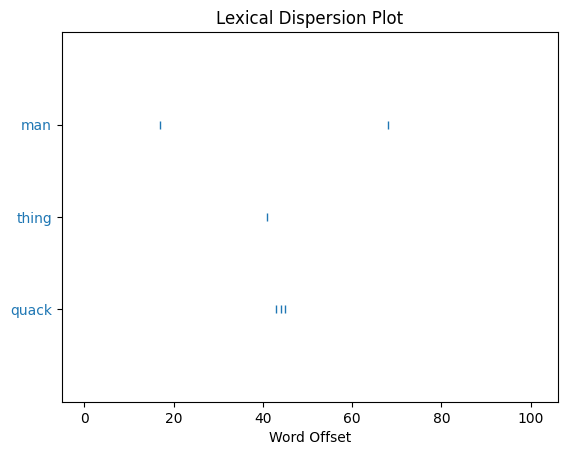

In [12]:
t.dispersion_plot(['man', 'thing', 'quack']) # Reveals patterns in word positions. Each stripe represents an instance of a word, and each row represents the entire text.

<Axes: xlabel='Samples', ylabel='Counts'>

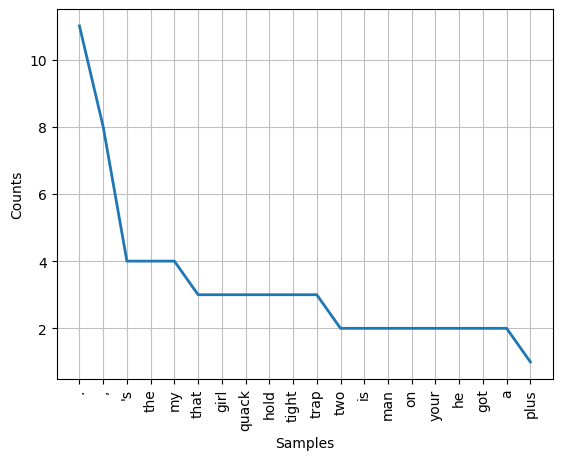

In [13]:

t.plot(20) # plots 20 most common tokens

In [14]:

t.vocab()

FreqDist({'.': 11, ',': 8, "'s": 4, 'the': 4, 'my': 4, 'that': 3, 'girl': 3, 'quack': 3, 'hold': 3, 'tight': 3, ...})

In [15]:
# reuters is a corpus of news documents.
nltk.download('reuters')

[nltk_data] Downloading package reuters to
[nltk_data]     /Users/bernardoquindimil/nltk_data...
[nltk_data]   Package reuters is already up-to-date!


True

In [16]:
from nltk.corpus import reuters
text = Text(reuters.words()) # .words() is one method corpus readers provide for reading data from a corpus. We will learn more about these methods in Chapter 2.
text.common_contexts(['August', 'June']) # It seems that .common_contexts() takes 2 words which are used similarly and displays where they are used similarly. It also seems that '_' indicates where the words would be in the text.

in_1986 in_, in_. in_1985 begins_1 last_. in_and last_, since_1985
and_and in_1987 since_1984 of_. for_shipment and_, ,_, -_) last_to
in_last by_.


Deriving N-Grams from Text

In [17]:
# 1. Tokenization

s = "Le temps est un grand maître, dit-on, le malheur est qu'il tue ses élèves."
s = s.lower()

In [18]:
from nltk.tokenize import RegexpTokenizer
tokenizer = RegexpTokenizer("[a-zA-Z'`éèî]+")
s_tokenized = tokenizer.tokenize(s)
s_tokenized

['le',
 'temps',
 'est',
 'un',
 'grand',
 'maître',
 'dit',
 'on',
 'le',
 'malheur',
 'est',
 "qu'il",
 'tue',
 'ses',
 'élèves']

In [19]:
from nltk.util import ngrams
generated_4grams = []

for word in s_tokenized:
    generated_4grams.append(list(ngrams(word, 4, pad_left=True, pad_right=True, left_pad_symbol='_', right_pad_symbol='_'))) # n is 4.
generated_4grams

[[('_', '_', '_', 'l'),
  ('_', '_', 'l', 'e'),
  ('_', 'l', 'e', '_'),
  ('l', 'e', '_', '_'),
  ('e', '_', '_', '_')],
 [('_', '_', '_', 't'),
  ('_', '_', 't', 'e'),
  ('_', 't', 'e', 'm'),
  ('t', 'e', 'm', 'p'),
  ('e', 'm', 'p', 's'),
  ('m', 'p', 's', '_'),
  ('p', 's', '_', '_'),
  ('s', '_', '_', '_')],
 [('_', '_', '_', 'e'),
  ('_', '_', 'e', 's'),
  ('_', 'e', 's', 't'),
  ('e', 's', 't', '_'),
  ('s', 't', '_', '_'),
  ('t', '_', '_', '_')],
 [('_', '_', '_', 'u'),
  ('_', '_', 'u', 'n'),
  ('_', 'u', 'n', '_'),
  ('u', 'n', '_', '_'),
  ('n', '_', '_', '_')],
 [('_', '_', '_', 'g'),
  ('_', '_', 'g', 'r'),
  ('_', 'g', 'r', 'a'),
  ('g', 'r', 'a', 'n'),
  ('r', 'a', 'n', 'd'),
  ('a', 'n', 'd', '_'),
  ('n', 'd', '_', '_'),
  ('d', '_', '_', '_')],
 [('_', '_', '_', 'm'),
  ('_', '_', 'm', 'a'),
  ('_', 'm', 'a', 'î'),
  ('m', 'a', 'î', 't'),
  ('a', 'î', 't', 'r'),
  ('î', 't', 'r', 'e'),
  ('t', 'r', 'e', '_'),
  ('r', 'e', '_', '_'),
  ('e', '_', '_', '_')],
 [('_', '_

In [20]:
generated_4grams = [word for sublist in generated_4grams for word in sublist]
generated_4grams[:10]

[('_', '_', '_', 'l'),
 ('_', '_', 'l', 'e'),
 ('_', 'l', 'e', '_'),
 ('l', 'e', '_', '_'),
 ('e', '_', '_', '_'),
 ('_', '_', '_', 't'),
 ('_', '_', 't', 'e'),
 ('_', 't', 'e', 'm'),
 ('t', 'e', 'm', 'p'),
 ('e', 'm', 'p', 's')]

In [21]:
# 2. Obtaining n-grams (n = 4)
ng_list_4grams = generated_4grams
for idx, val in enumerate(generated_4grams):
    ng_list_4grams[idx] = ''.join(val)
ng_list_4grams

['___l',
 '__le',
 '_le_',
 'le__',
 'e___',
 '___t',
 '__te',
 '_tem',
 'temp',
 'emps',
 'mps_',
 'ps__',
 's___',
 '___e',
 '__es',
 '_est',
 'est_',
 'st__',
 't___',
 '___u',
 '__un',
 '_un_',
 'un__',
 'n___',
 '___g',
 '__gr',
 '_gra',
 'gran',
 'rand',
 'and_',
 'nd__',
 'd___',
 '___m',
 '__ma',
 '_maî',
 'maît',
 'aîtr',
 'ître',
 'tre_',
 're__',
 'e___',
 '___d',
 '__di',
 '_dit',
 'dit_',
 'it__',
 't___',
 '___o',
 '__on',
 '_on_',
 'on__',
 'n___',
 '___l',
 '__le',
 '_le_',
 'le__',
 'e___',
 '___m',
 '__ma',
 '_mal',
 'malh',
 'alhe',
 'lheu',
 'heur',
 'eur_',
 'ur__',
 'r___',
 '___e',
 '__es',
 '_est',
 'est_',
 'st__',
 't___',
 '___q',
 '__qu',
 "_qu'",
 "qu'i",
 "u'il",
 "'il_",
 'il__',
 'l___',
 '___t',
 '__tu',
 '_tue',
 'tue_',
 'ue__',
 'e___',
 '___s',
 '__se',
 '_ses',
 'ses_',
 'es__',
 's___',
 '___é',
 '__él',
 '_élè',
 'élèv',
 'lève',
 'èves',
 'ves_',
 'es__',
 's___']

In [22]:
# 3. Sorting n-grams by frequency (n = 4)
freq_4grams = {}

for ngram in ng_list_4grams:
    if ngram not in freq_4grams:
        freq_4grams.update({ngram: 1})
    else:
        ngram_occurrences = freq_4grams[ngram]
        freq_4grams.update({ngram: ngram_occurrences + 1})
        
from operator import itemgetter # The operator module exports a set of efficient functions corresponding to the intrinsic operators of Python. For example, operator.add(x, y) is equivalent to the expression x + y.

freq_4grams_sorted = sorted(freq_4grams.items(), key=itemgetter(1), reverse=True)[0:300] # We only keep the 300 most popular n-grams. This was suggested in the original paper written about n-grams.
freq_4grams_sorted

[('e___', 4),
 ('s___', 3),
 ('t___', 3),
 ('___l', 2),
 ('__le', 2),
 ('_le_', 2),
 ('le__', 2),
 ('___t', 2),
 ('___e', 2),
 ('__es', 2),
 ('_est', 2),
 ('est_', 2),
 ('st__', 2),
 ('n___', 2),
 ('___m', 2),
 ('__ma', 2),
 ('es__', 2),
 ('__te', 1),
 ('_tem', 1),
 ('temp', 1),
 ('emps', 1),
 ('mps_', 1),
 ('ps__', 1),
 ('___u', 1),
 ('__un', 1),
 ('_un_', 1),
 ('un__', 1),
 ('___g', 1),
 ('__gr', 1),
 ('_gra', 1),
 ('gran', 1),
 ('rand', 1),
 ('and_', 1),
 ('nd__', 1),
 ('d___', 1),
 ('_maî', 1),
 ('maît', 1),
 ('aîtr', 1),
 ('ître', 1),
 ('tre_', 1),
 ('re__', 1),
 ('___d', 1),
 ('__di', 1),
 ('_dit', 1),
 ('dit_', 1),
 ('it__', 1),
 ('___o', 1),
 ('__on', 1),
 ('_on_', 1),
 ('on__', 1),
 ('_mal', 1),
 ('malh', 1),
 ('alhe', 1),
 ('lheu', 1),
 ('heur', 1),
 ('eur_', 1),
 ('ur__', 1),
 ('r___', 1),
 ('___q', 1),
 ('__qu', 1),
 ("_qu'", 1),
 ("qu'i", 1),
 ("u'il", 1),
 ("'il_", 1),
 ('il__', 1),
 ('l___', 1),
 ('__tu', 1),
 ('_tue', 1),
 ('tue_', 1),
 ('ue__', 1),
 ('___s', 1),
 ('__s

In [23]:
# 4. Obtaining n-grams for multiple values of n
from nltk import everygrams

s_clean = ' '.join(s_tokenized) # For the code below we need the raw sentence as opposed to the tokens.
s_clean

"le temps est un grand maître dit on le malheur est qu'il tue ses élèves"

In [24]:
def ngram_extractor(sent):
    return [''.join(ng) for ng in everygrams(sent.replace(' ', '_ _'), 1, 4) 
            if ' ' not in ng and '\n' not in ng and ng != ('_',)]

ngram_extractor(s_clean)

['l',
 'le',
 'le_',
 'e',
 'e_',
 '_t',
 '_te',
 '_tem',
 't',
 'te',
 'tem',
 'temp',
 'e',
 'em',
 'emp',
 'emps',
 'm',
 'mp',
 'mps',
 'mps_',
 'p',
 'ps',
 'ps_',
 's',
 's_',
 '_e',
 '_es',
 '_est',
 'e',
 'es',
 'est',
 'est_',
 's',
 'st',
 'st_',
 't',
 't_',
 '_u',
 '_un',
 '_un_',
 'u',
 'un',
 'un_',
 'n',
 'n_',
 '_g',
 '_gr',
 '_gra',
 'g',
 'gr',
 'gra',
 'gran',
 'r',
 'ra',
 'ran',
 'rand',
 'a',
 'an',
 'and',
 'and_',
 'n',
 'nd',
 'nd_',
 'd',
 'd_',
 '_m',
 '_ma',
 '_maî',
 'm',
 'ma',
 'maî',
 'maît',
 'a',
 'aî',
 'aît',
 'aîtr',
 'î',
 'ît',
 'îtr',
 'ître',
 't',
 'tr',
 'tre',
 'tre_',
 'r',
 're',
 're_',
 'e',
 'e_',
 '_d',
 '_di',
 '_dit',
 'd',
 'di',
 'dit',
 'dit_',
 'i',
 'it',
 'it_',
 't',
 't_',
 '_o',
 '_on',
 '_on_',
 'o',
 'on',
 'on_',
 'n',
 'n_',
 '_l',
 '_le',
 '_le_',
 'l',
 'le',
 'le_',
 'e',
 'e_',
 '_m',
 '_ma',
 '_mal',
 'm',
 'ma',
 'mal',
 'malh',
 'a',
 'al',
 'alh',
 'alhe',
 'l',
 'lh',
 'lhe',
 'lheu',
 'h',
 'he',
 'heu',
 'heur'

## Spacy

In [25]:
# Import spacy and English models
import spacy

nlp = spacy.load('en_core_web_sm')

In [26]:

# Process sentences 'Hello, world. Natural Language Processing in 10 lines of code.' using spaCy
doc = nlp(u'Hello, world. Natural Language Processing in 10 lines of code.')

In [27]:
# Get first token of the processed document
token = doc[0]
print(token)

# Print sentences (one sentence per line)
for sent in doc.sents:
    print(sent)

Hello
Hello, world.
Natural Language Processing in 10 lines of code.


In [28]:
# For each token, print corresponding part of speech tag
for token in doc:
    print('{} - {}'.format(token, token.pos_))

Hello - INTJ
, - PUNCT
world - NOUN
. - PUNCT
Natural - ADJ
Language - PROPN
Processing - NOUN
in - ADP
10 - NUM
lines - NOUN
of - ADP
code - NOUN
. - PUNCT


We have the speech tags and we have all of the tokens in a sentence, but how do we relate the two to uncover the syntax in a sentence? Syntactic dependencies describe how each type of word relates to each other in a sentence, this is important in NLP in order to extract structure and understand grammar in plain text.

In [ ]:
# Write a function that walks up the syntactic tree of the given token and collects all tokens to the root token (including root token).

'''
def tokens_to_root(token):
    """
    Walk up the syntactic tree, collecting tokens to the root of the given `token`.
    :param token: Spacy token
    :return: list of Spacy tokens
    """
    tokens_to_r = []
    while token.head is not token:
        tokens_to_r.append(token)
        token = token.head
        tokens_to_r.append(token)

    return tokens_to_r

# For every token in document, print it's tokens to the root
for token in doc:
    print('{} --> {}'.format(token, tokens_to_root(token)))

# Print dependency labels of the tokens
for token in doc:
    print('-> '.join(['{}-{}'.format(dependent_token, dependent_token.dep_) for dependent_token in tokens_to_root(token)]))
'''

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1040b8f10>>
Traceback (most recent call last):
  File "/Users/bernardoquindimil/miniconda3/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


A named entity is any real world object such as a person, location, organisation or product with a proper name.

In [ ]:
# Print all named entities with named entity types

doc_2 = nlp(u"I went to Paris where I met my old friend Jack from uni.")
for ent in doc_2.ents:
    print('{} - {}'.format(ent, ent.label_))

Paris - GPE
Jack - PERSON


In [ ]:
# Print noun chunks for doc_2
print([chunk for chunk in doc_2.noun_chunks])

[I, Paris, I, my old friend, Jack, uni]


In [31]:
# For every token in doc_2, print log-probability of the word, estimated from counts from a large corpus 
for token in doc_2:
    print(token, ',', token.prob)

I , -20.0
went , -20.0
to , -20.0
Paris , -20.0
where , -20.0
I , -20.0
met , -20.0
my , -20.0
old , -20.0
friend , -20.0
Jack , -20.0
from , -20.0
uni , -20.0
. , -20.0


A word embedding is a representation of a word, and by extension a whole language corpus, in a vector or other form of numerical mapping. This allows words to be treated numerically with word similarity represented as spatial difference in the dimensions of the word embedding mapping.

In [34]:
# For a given document, calculate similarity between 'apples' and 'oranges' and 'boots' and 'hippos'
doc = nlp(u"Apples and oranges are similar. Boots and hippos aren't.")
apples = doc[0]
oranges = doc[2]
boots = doc[6]
hippos = doc[8]
print(apples.similarity(oranges))
print(boots.similarity(hippos))

print()
# Print similarity between sentence and word 'fruit'
apples_sent, boots_sent = doc.sents
fruit = doc.vocab[u'fruit']
print(apples_sent.similarity(fruit))
print(boots_sent.similarity(fruit))

0.44510018825531006
0.11997263878583908



/var/folders/fc/g29yl9x15nq9_jmdqtk6q1_80000gn/T/ipykernel_37918/635242888.py:7: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Token.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  print(apples.similarity(oranges))
/var/folders/fc/g29yl9x15nq9_jmdqtk6q1_80000gn/T/ipykernel_37918/635242888.py:8: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Token.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use con

ValueError: [E010] Word vectors set to length 0. This may be because you don't have a model installed or loaded, or because your model doesn't include word vectors. For more info, see the docs:
https://spacy.io/usage/models

In [35]:
# Cargar el modelo de lenguaje en inglés con vectores de palabras
nlp = spacy.load("en_core_web_md")

# Ejemplo de texto
text = "Apples and oranges are both fruit. Boots are a type of footwear."

# Procesar el texto con spaCy
doc = nlp(text)

# Dividir el texto en oraciones
apples_sent, boots_sent = list(doc.sents)

# Obtener el vector de la palabra "fruit"
fruit = doc.vocab["fruit"]

# Calcular la similitud
print(apples_sent.similarity(fruit))
print(boots_sent.similarity(fruit))

0.6902844309806824
0.2295970618724823
